# EDA for Top Spotify Songs in 73 Countries (Daily Updated) dataset.
- https://www.kaggle.com/datasets/asaniczka/top-spotify-songs-in-73-countries-daily-updated/versions/493
- Version 608 & version 607

In [1]:
import pandas as pd
import pathlib as Path
import matplotlib.pyplot as plt
import seaborn as sns

# Mina "konstanter" rörs ej
Path = "../data/raw/universal_top_spotify_songs_Version_608.csv"
df = pd.read_csv(Path)

In [2]:
# Utforska rader + kolumner
print("=== SHAPE (Rows, columns) ===")
print(df.shape)

=== SHAPE (Rows, columns) ===
(2110316, 25)


In [3]:
# Utforska datatyperna
print("\n=== DTYPES (Data types) ===")
print(df.dtypes)



=== DTYPES (Data types) ===
spotify_id                str
name                      str
artists                   str
daily_rank              int64
daily_movement          int64
weekly_movement         int64
country                   str
snapshot_date             str
popularity              int64
is_explicit              bool
duration_ms             int64
album_name                str
album_release_date        str
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
dtype: object


In [4]:
# Söka efter NULL values
print("\n=== NULL-VALUES (How much trash do I have?) ===")
print(df.isnull().sum())


=== NULL-VALUES (How much trash do I have?) ===
spotify_id                0
name                     30
artists                  29
daily_rank                0
daily_movement            0
weekly_movement           0
country               28908
snapshot_date             0
popularity                0
is_explicit               0
duration_ms               0
album_name              822
album_release_date      659
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
valence                   0
tempo                     0
time_signature            0
dtype: int64


In [5]:
# Första 3 rows
df.head(3)

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,Alex Warren,1,1,0,NaN,2025-06-11,95,False,...,2,-6.141,1,0.0600,0.704000,0.000007,0.0550,0.391,168.115,3
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,Sabrina Carpenter,2,-1,48,NaN,2025-06-11,89,True,...,7,-5.087,1,0.0572,0.122000,0.000000,0.3170,0.811,123.010,4
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,sombr,3,0,1,NaN,2025-06-11,98,False,...,1,-2.291,1,0.0301,0.000094,0.000088,0.0929,0.235,92.855,4


## From raw data to cleaned and processed data. [Taking my insights from quick and basic EDA and processing that data](../docs/eda_insights/top_spotify_songs_countries.md)

In [8]:
# 1) Hantera saknade länder, NaN (Null values) -> Global
df['country'] = df['country'].fillna('Global')

# 2) Droppa de FÅ rader där artistnamn eller låtnamn saknas(Är 59stycken totalt. Irrelevant på 2.1miljoner)
df = df.dropna(subset=['name', 'artists'])

# 3) Konvertera datumsträng till riktiga DateTime objects.
# === KRITISKT FÖR TIDSANALYSEN ===
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# 4) Skapa ny column med Månad för att underlätta för att analysera "säsongs trender"
df['month'] = df['snapshot_date'].dt.month

print("Cleaning done. New Null-Values:")
print(df.isnull().sum())

Cleaning done. New Null-Values:
spotify_id              0
name                    0
artists                 0
daily_rank              0
daily_movement          0
weekly_movement         0
country                 0
snapshot_date           0
popularity              0
is_explicit             0
duration_ms             0
album_name            792
album_release_date    630
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
month                   0
dtype: int64


## Data is processed and cleaned for my use purposes. 
**What am I looking for?:**
- Is there ANY correlation with seasons and happiness in music?
    - Yes. There is. Happiness PEAKS in July and around Christmas.
- Is there ANY correlation with seasons and danceability in music?
    - Yes. There is. Danceability PEAKS in July
- is there ANY correlation with seasons and energy in music?
    - Yes there SEEMS to be. 



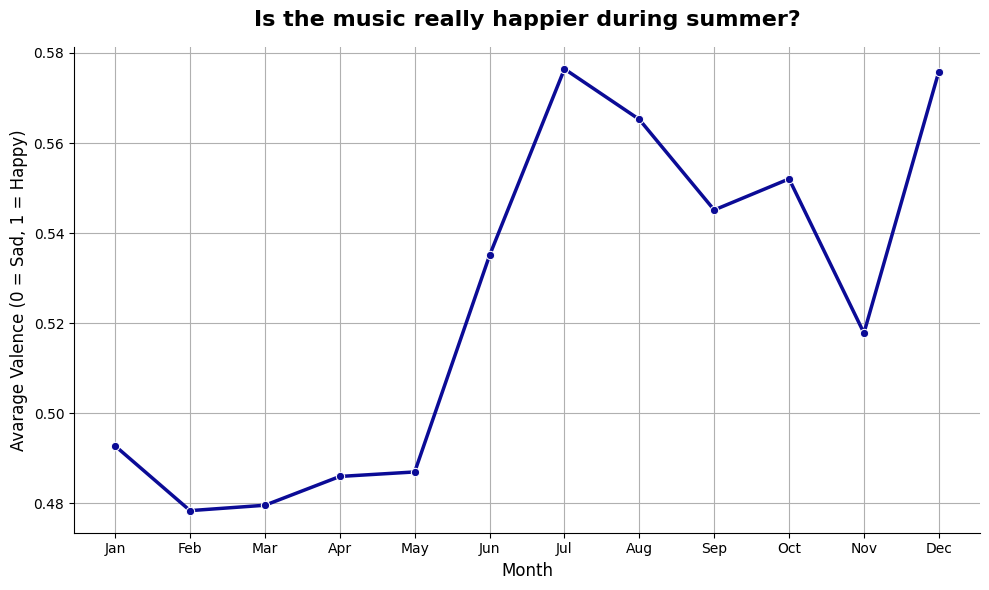

In [27]:
# Filtrerar ut endast den globala datan för att inte bli helt förvirrad av alla länder
df_global = df[df["country"] == "Global"]
# Gruppera på månad och få fram ett snitt på valence(glädjen)
monthly_mood = df_global.groupby("month")["valence"].mean().reset_index()

# ===== PLOTTING =====
# OOP-way av att plotta istället
fix, ax = plt.subplots(figsize=(10, 6))

# Lineplot
sns.lineplot(
    data=monthly_mood,
    x="month",
    y="valence",
    marker="o",
    color="#0B0B96",
    ax=ax,
    linewidth=2.5,
)

# Data storytelling: Rensar bort onödigt skräp och gör allting tydligare
ax.set_title('Is the music really happier during summer?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avarage Valence (0 = Sad, 1 = Happy)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Bort med spines och på med grid
ax.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

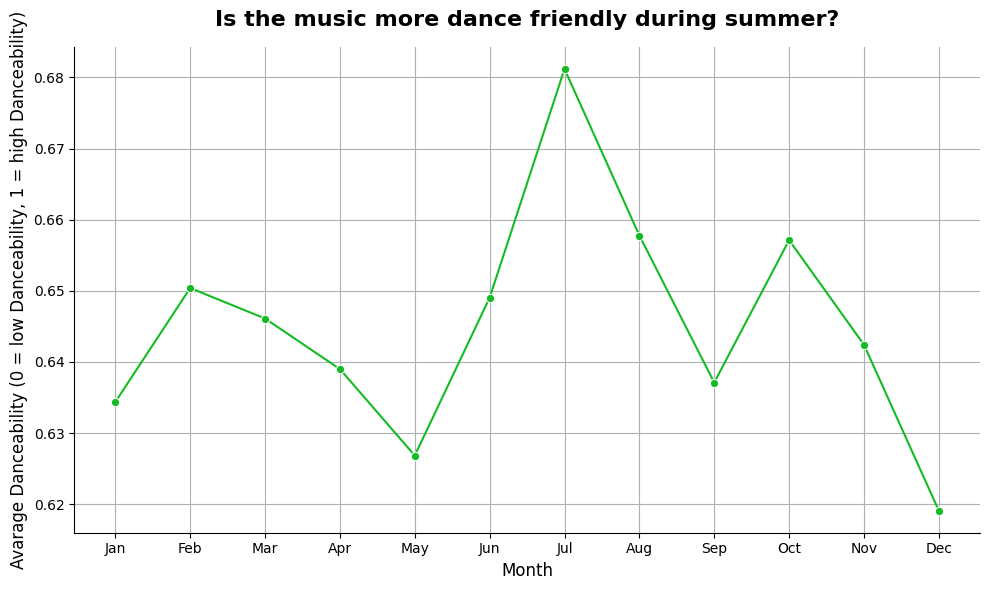

In [26]:
# Filtrerar ut endast den globala datan för att inte bli helt förvirrad av alla länder
df_global = df[df["country"] == "Global"]
# Gruppera på månad och få fram ett snitt på valence(glädjen)
monthly_mood = df_global.groupby("month")["danceability"].mean().reset_index()

# ===== PLOTTING =====
# OOP-way av att plotta istället
fix, ax = plt.subplots(figsize=(10, 6))

# Lineplot
sns.lineplot(
    data=monthly_mood,
    x="month",
    y="danceability",
    marker="o",
    color="#14BB24",
    ax=ax,
    linewidth=1.5,
)

# Data storytelling: Rensar bort onödigt skräp och gör allting tydligare
ax.set_title('Is the music more dance friendly during summer?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avarage Danceability (0 = low Danceability, 1 = high Danceability)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Bort med spines och få fram grid
ax.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

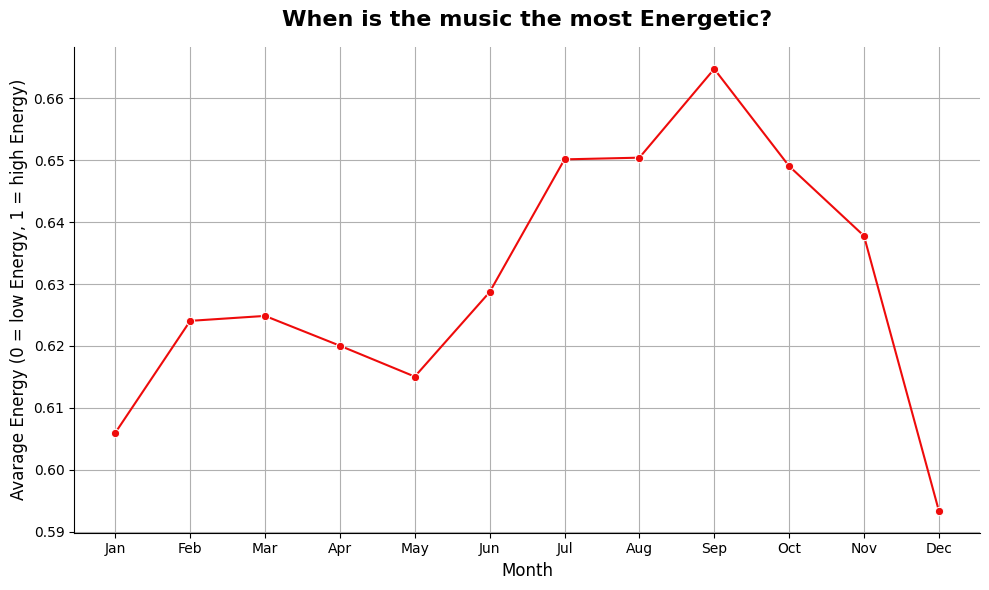

In [25]:
# Filtrerar ut endast den globala datan för att inte bli helt förvirrad av alla länder
df_global = df[df["country"] == "Global"]
# Gruppera på månad och få fram ett snitt på valence(glädjen)
monthly_mood = df_global.groupby("month")["energy"].mean().reset_index()

# ===== PLOTTING =====
# OOP-way av att plotta istället
fix, ax = plt.subplots(figsize=(10, 6))

# Lineplot
sns.lineplot(
    data=monthly_mood,
    x="month",
    y="energy",
    marker="o",
    color="#EE0B0B",
    ax=ax,
    linewidth=1.5,
)

# Data storytelling: Rensar bort onödigt skräp och gör allting tydligare
ax.set_title('When is the music the most Energetic?', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avarage Energy (0 = low Energy, 1 = high Energy)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Bort med spines och få fram grid
ax.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Insights from three diagrams meassuring Happiness(Valence), Danceability and Energy. 
- Three diagrams with two of them being a bit linked together but the energy diagram shows different and interesting numbers.
    - Time to create a plot for the three questions above and then a **heatmap** to try and find more insights.

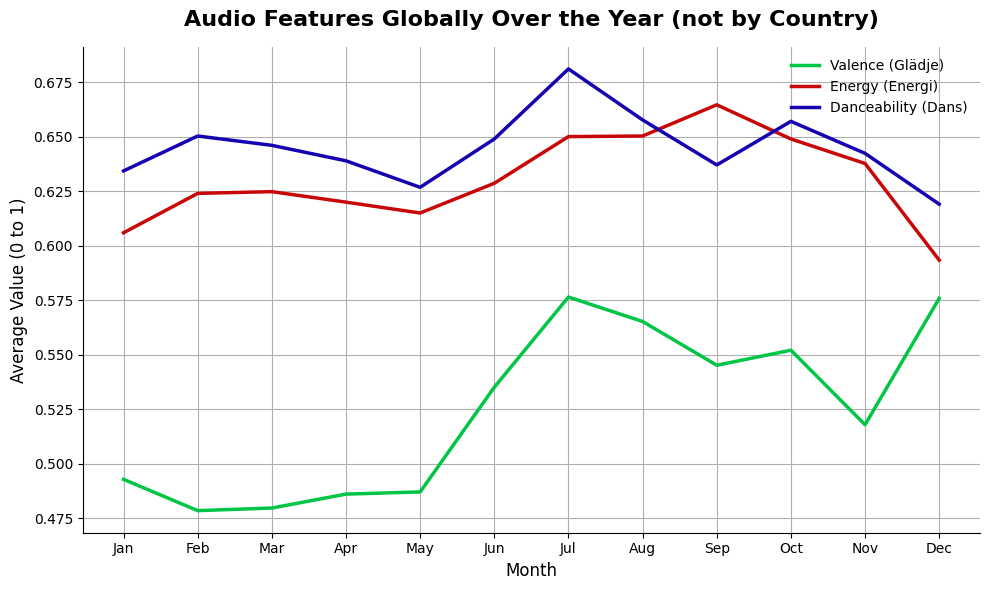

In [36]:
# Grupperar på månad och tar snittet för ALLA tre kolumner samtidigt(plots ovan denna)
monthly_metrics = df_global.groupby("month")[["valence", "energy", "danceability"]].mean().reset_index()

# Sätt upp grafen jag ska använda mig av
fig, ax = plt.subplots(figsize=(10, 6))

# Rita tre linjer på samma axel och ange tre olika färger för att se skillnaden
sns.lineplot(data=monthly_metrics, x="month", y="valence", label="Valence (Glädje)", color="#00C545", linewidth=2.5, ax=ax)
sns.lineplot(data=monthly_metrics, x="month", y="energy", label="Energy (Energi)", color="#C80808", linewidth=2.5, ax=ax)
sns.lineplot(data=monthly_metrics, x="month", y="danceability", label="Danceability (Dans)", color="#1503B1", linewidth=2.5, ax=ax)

# Formatering på hur jag vill att allting ska se ut.
ax.set_title('Audio Features Globally Over the Year (not by Country)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Value (0 to 1)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# legend (förklaring) och ta bort ramar
ax.legend(frameon=False)
ax.grid(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

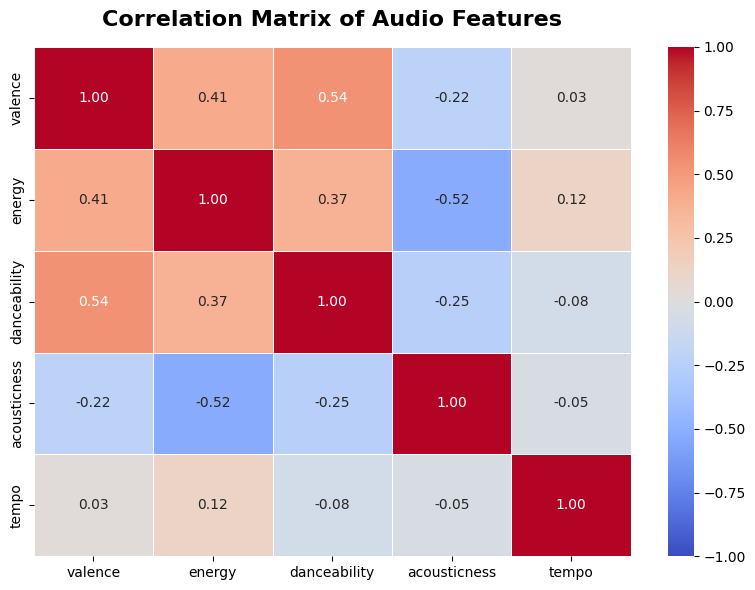

In [ ]:
# Plocka bara ut de numeriska ljud kolumnerna ifrån datasettet
audio_cols = ["valence", "energy", "danceability", "acousticness", "tempo"]
df_audio = df_global[audio_cols]

# Räkna ut korrelationsmatrisen
correlation_matrix = df_audio.corr()

# Plotta en Heatmap med Seaborn 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, ax=ax)

ax.set_title('Correlation matrix of Audio Features', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()